Lecture: AI I - Advanced 

Previous:
[**Chapter 1.2: Multilayer Perceptron**](../02_mlp.ipynb)

---

# Exercise 1.2: Multilayer Perceptron

> Hint: When doing the exercises put your solution in the designated "Solution" section:
> ```python
> # Solution (put your code here)
> ```

## Task 1: Diabetes Regression with Multi-Layer Perceptron

The diabetes dataset contains 442 samples with 10 baseline variables (age, sex, BMI, blood pressure, and 6 blood serum measurements). The target is a quantitative measure of disease progression one year after baseline.

**Tasks**
- Data Exploration & Understanding
- Data preparation
- Build Model a Multi-Layer Perceptron for regression
- Train the model 
- Evaluate the model performance using appropriate regression metrics (e.g. MSE, MAE) and Tensorboard

In [1]:
# prerequisites (don't edit this block)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

In [ ]:
# Solution (put your code here)
import torch

from datetime import datetime

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir=f'./data/runs/run_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

# n = x.shape[0] # Number of samples in the dataset
# ids = torch.randperm(len(x)) # Randomly permute the indices to shuffle the data before splitting into train, val, and test sets
# train_ids = ids[:int(n * .6)] # Use the first 60% of the shuffled indices for training
# val_ids = ids[int(n * .6):int(n * .8)] # Use the next 20% of the shuffled indices for validation
# test_ids = ids[int(n * .8):] # Use the last 20% of the shuffled indices for testing

# Daten bereits standardisiert, daher direkt aufteilen

# Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

# In Tensoren umwandeln 
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # Target braucht Spaltenform
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Validierungsdaten erstellen
X_val = X_test[:len(X_test)//2]
y_val = y_test[:len(y_test)//2]


batch_size = 32
# DataLoader erstellen
train_loader = DataLoader(
    TensorDataset(X_train, y_train), 
    batch_size=batch_size, 
    shuffle=True # Wieso shufflen? Weil wir die Trainingsdaten in jeder Epoche in einer anderen Reihenfolge präsentieren wollen, um die Generalisierung des Modells zu verbessern.
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test), 
    batch_size=batch_size, 
    shuffle=False # Wieso nicht shufflen? Weil wir die Testdaten in der Reihenfolge behalten wollen, um die Ergebnisse später besser interpretieren zu können.
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val), 
    batch_size=batch_size, 
    shuffle=False # Wieso nicht shufflen? Weil wir die Validierungsdaten in der Reihenfolge behalten wollen, um die Ergebnisse später besser interpretieren zu können.
)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches per epoch: 9
Validation batches: 3
Test batches: 6


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class DiabetesModel(nn.Module):
    def __init__(self, input_dim):
        super(DiabetesModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), # Input Layer -> 64 Neuronen
            nn.Linear(64, 32), # Hidden Layer -> 32 Neuronen
            nn.Linear(32, 1) # Output Layer -> 1 Neuron (für Regression)
        )

    def forward(self, x):
        x = F.relu(self.network[0](x)) # ReLU Aktivierungsfunktion nach dem ersten Layer
        x = F.relu(self.network[1](x)) # ReLU Aktivierungsfunktion nach dem zweiten Layer
        x = self.network[2](x) # Kein Aktivierungsfunktion nach dem letzten Layer, da es sich um eine Regression handelt
        return x

In [4]:

model = DiabetesModel(X_train.shape[1]) # input_dim = number of features in the dataset

# Log the model architecture to TensorBoard
writer.add_graph(model, X_train[:batch_size]) # Log the model architecture using a batch of training data (batch size = 32)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
DiabetesModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2,817
Trainable parameters: 2,817


In [5]:
# criterion = nn.MSELoss() # Mean Squared Error Loss for regression tasks
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with learning rate 0.001
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, 
#     mode='min',      # Reduce LR when validation loss stops decreasing
#     factor=0.1,      # Reduce LR by a factor of 0.1 (i.e., new_lr = lr * factor)
#     patience=5,      # Wait for 5 epochs before reducing LR
# )



# epochs = 100
# for epoch in range(epochs):
#     model.train()
#     train_loss = 0.0
#     for batch_x, batch_y in train_loader:
#         optimizer.zero_grad()
#         outputs = model(batch_x)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item()
    
#     # Logging
#     avg_loss = train_loss / len(train_loader)
#     writer.add_scalar('Loss/train', avg_loss, epoch)

# writer.close()

### Alternativ:
(Aus 02_mlp.ipynb kopiert)

In [14]:
# Define the loss function, optimizer, and learning rate scheduler for training
criterion = nn.MSELoss() # Mean Squared Error Loss for regression tasks
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with learning rate of 0.001
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # Reduce LR when validation loss stops decreasing
    factor=0.5,      # Multiply LR by 0.5
    patience=10,     # Wait 10 epochs before reducing
)

def train_epoch(model, train_loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()  # Set model to training mode
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
    
    return train_loss / len(train_loader.dataset)  # Return average loss

def validate(model, val_loader, criterion):
    """Validate the model"""
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    
    with torch.no_grad():  # Disable gradient computation for efficiency
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    
    return val_loss / len(val_loader.dataset)

def compute_metrics(model, data_loader):
    """Compute detailed regression metrics"""
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            predictions = model(batch_X)
            all_predictions.append(predictions)
            all_targets.append(batch_y)
    
    predictions = torch.cat(all_predictions, dim=0)
    targets = torch.cat(all_targets, dim=0)
    
    mse = F.mse_loss(predictions, targets).item()        
    return {
        'mse': mse,                                     # Mean Squared Error (MSE)
        'rmse': np.sqrt(mse),                           # Root Mean Squared Error (RMSE)
        'mae': F.l1_loss(predictions, targets).item(),  # Mean Absolute Error (MAE)
    }

# Training loop
num_epochs = 200
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 20

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)

    # Validate
    val_loss = validate(model, val_loader, criterion)
    val_losses.append(val_loss)

    # Log losses to TensorBoard
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalars('Loss/Train_vs_Val', {'Train': train_loss, 'Validation': val_loss}, epoch)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), './data/model.pth')  # Save best model
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:7.4f} | "
              f"Val Loss: {val_loss:7.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

writer.close()

Epoch   1/200 | Train Loss: 3535.3316 | Val Loss: 3175.1735 | LR: 0.001000
Epoch  10/200 | Train Loss: 3452.0420 | Val Loss: 3126.8208 | LR: 0.001000
Epoch  20/200 | Train Loss: 3384.2445 | Val Loss: 3085.9804 | LR: 0.001000
Epoch  30/200 | Train Loss: 3323.9414 | Val Loss: 3053.7574 | LR: 0.001000
Epoch  40/200 | Train Loss: 3275.2819 | Val Loss: 3022.7407 | LR: 0.001000
Epoch  50/200 | Train Loss: 3230.1049 | Val Loss: 3004.5422 | LR: 0.001000
Epoch  60/200 | Train Loss: 3191.6863 | Val Loss: 2987.8817 | LR: 0.001000
Epoch  70/200 | Train Loss: 3159.2521 | Val Loss: 2980.5218 | LR: 0.001000
Epoch  80/200 | Train Loss: 3130.8425 | Val Loss: 2958.4623 | LR: 0.001000
Epoch  90/200 | Train Loss: 3107.6996 | Val Loss: 2961.9911 | LR: 0.001000
Epoch 100/200 | Train Loss: 3081.6492 | Val Loss: 2956.3473 | LR: 0.001000
Epoch 110/200 | Train Loss: 3066.3744 | Val Loss: 2961.7226 | LR: 0.001000
Epoch 120/200 | Train Loss: 3051.1044 | Val Loss: 2944.6426 | LR: 0.001000
Epoch 130/200 | Train Los

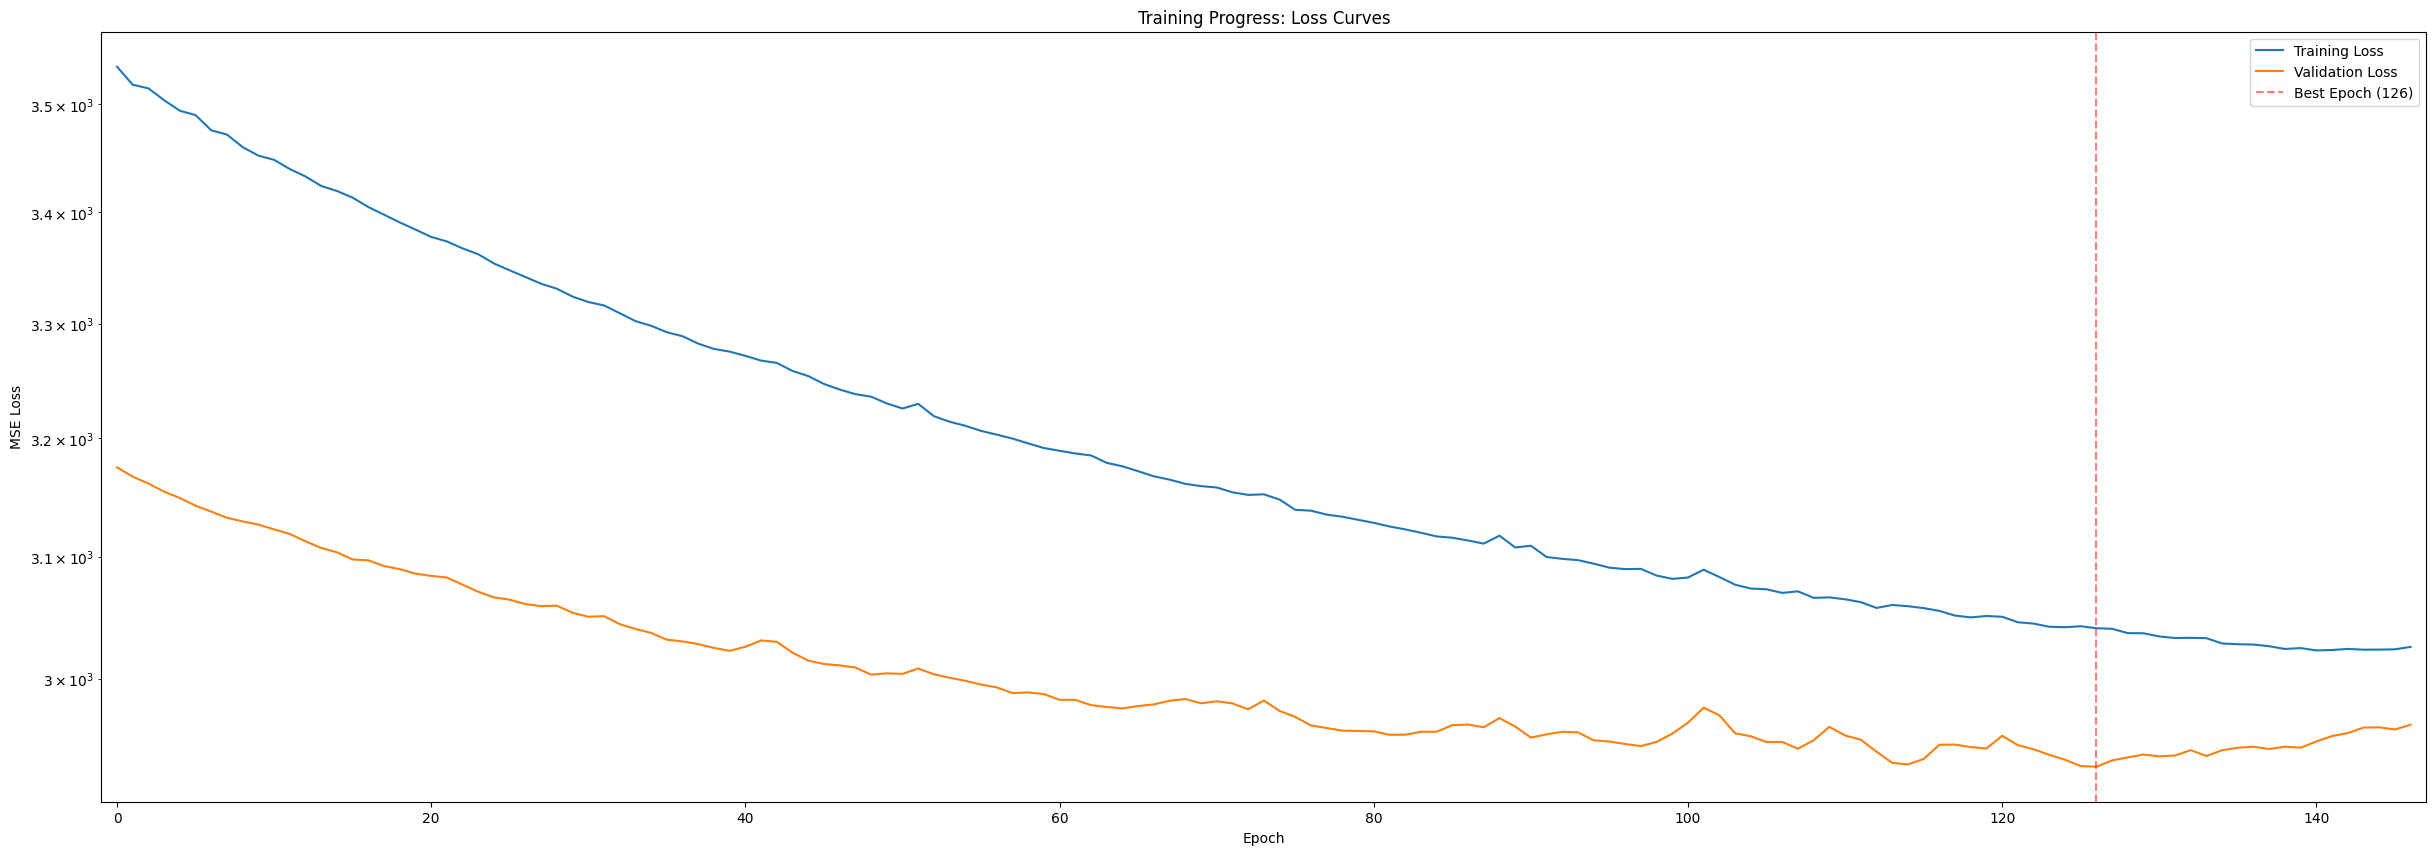

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(30, 10))
ax.plot(train_losses, label='Training Loss')
ax.plot(val_losses, label='Validation Loss')
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='Training Progress: Loss Curves', yscale='log', xlim=(-1, len(train_losses)))

# Mark best epoch
best_epoch = np.argmin(val_losses)
ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')

ax.legend()

In [8]:
model.load_state_dict(torch.load('./data/model.pth'))

train_metrics = compute_metrics(model, train_loader)
val_metrics = compute_metrics(model, val_loader)
test_metrics = compute_metrics(model, test_loader)  # Compute test metrics
print(f"MSE:  {test_metrics['mse']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f} (± ${test_metrics['rmse']:.2f}k average error)")
print(f"MAE:  {test_metrics['mae']:.4f} (${test_metrics['mae']:.2f}k average error)")

MSE:  3301.3545
RMSE: 57.4574 (± $57.46k average error)
MAE:  47.7428 ($47.74k average error)


In [9]:
y_test.flatten().shape, model(X_test).flatten().shape

(torch.Size([177]), torch.Size([177]))

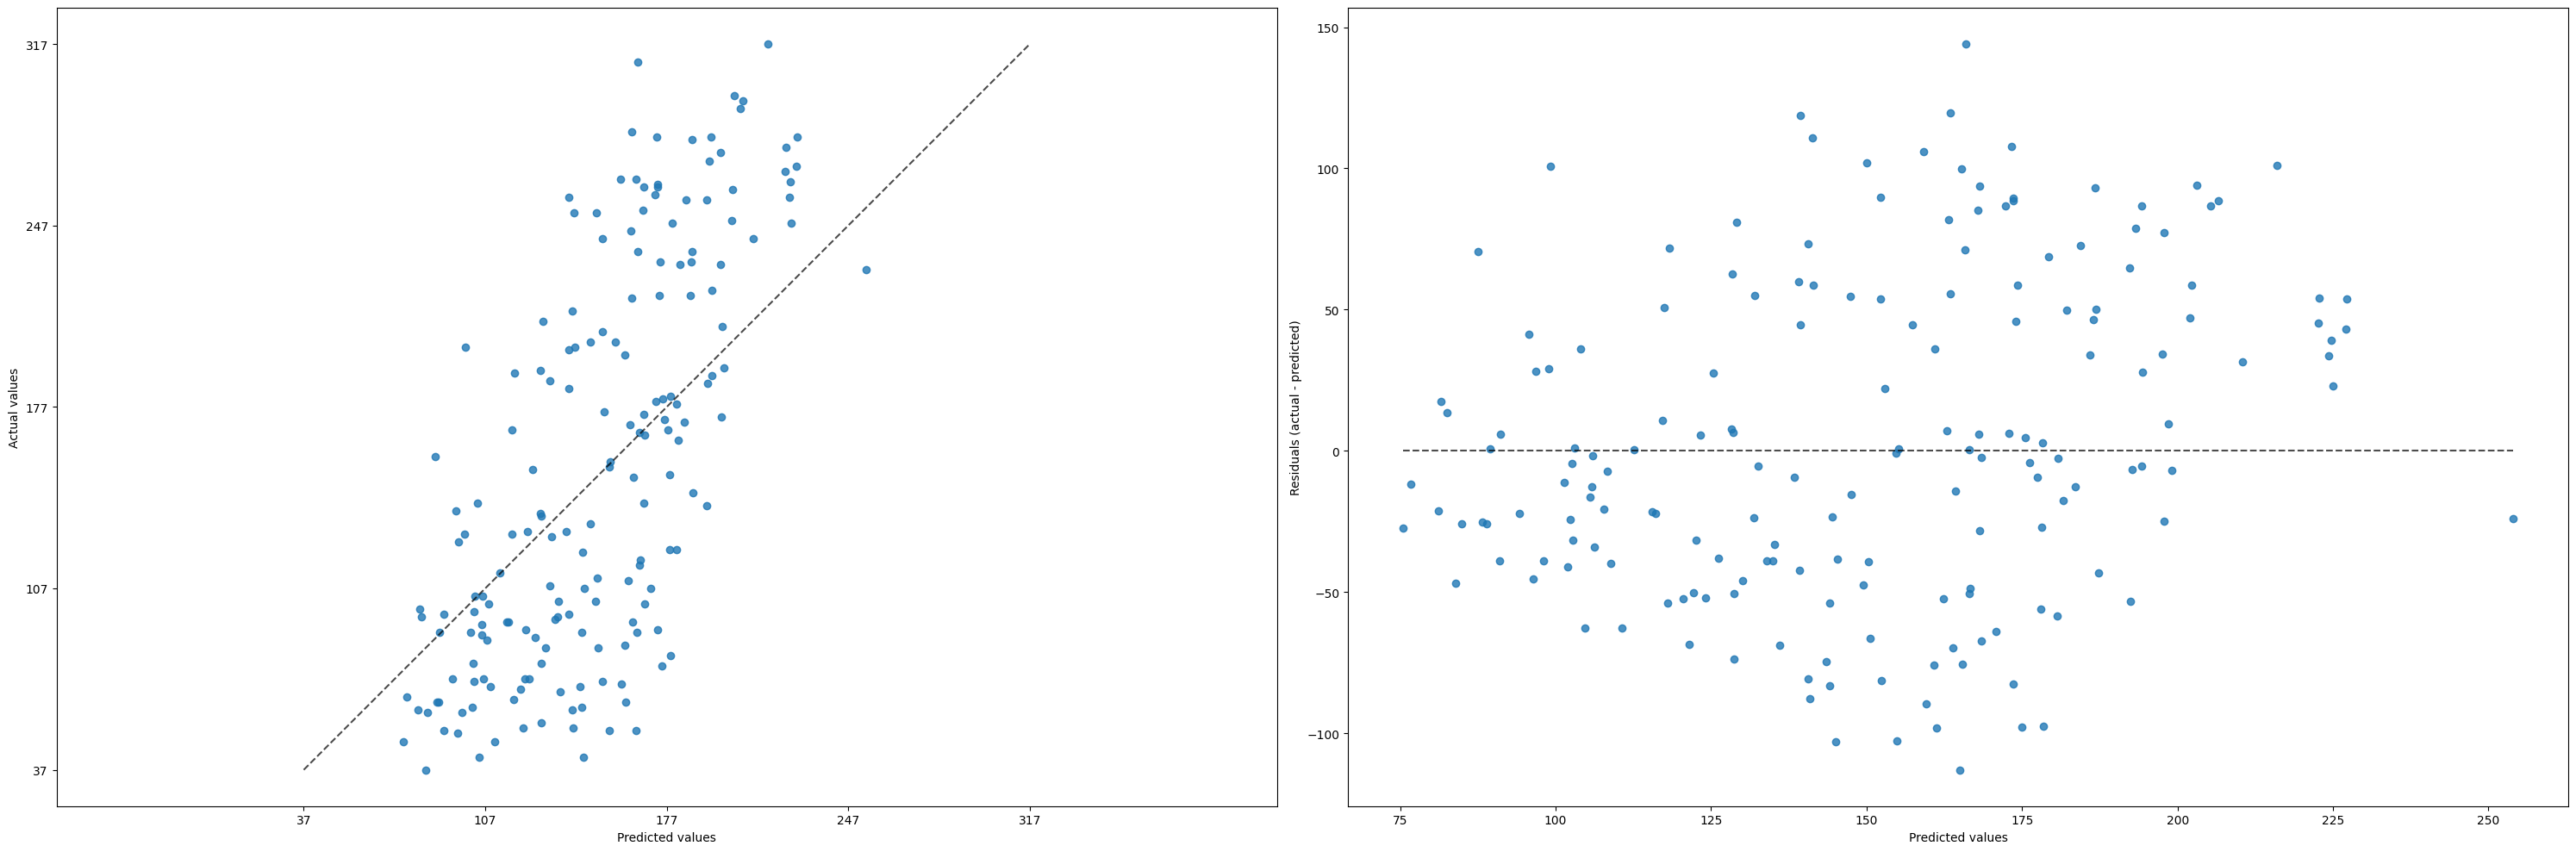

In [10]:
from sklearn.metrics import PredictionErrorDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

y_true = y_test.numpy()
y_pred = model(X_test).detach().numpy()

PredictionErrorDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax1,
    kind='actual_vs_predicted',
)
PredictionErrorDisplay.from_predictions(
    y_true,
    y_pred,
    kind='residual_vs_predicted',
    ax=ax2,
)
fig.tight_layout()

### Was sagt uns die erste Grafik? 
Sie zeigt die tatsächlichen Werte (y_true) auf der x-Achse und die vorhergesagten Werte (y_pred) auf der y-Achse. Wenn das Modell perfekt wäre, würden alle Punkte auf der Diagonalen liegen (y_true = y_pred). Je weiter die Punkte von der Diagonalen entfernt sind, desto größer ist der Fehler in den Vorhersagen.

### Was sagt uns die zweite Grafik? 
Sie zeigt die Residuen (y_true - y_pred) auf der y-Achse und die vorhergesagten Werte (y_pred) auf der x-Achse. Wenn die Residuen zufällig um die Null-Linie verteilt sind, deutet dies darauf hin, dass das Modell gut angepasst ist. Wenn es jedoch Muster in den Residuen gibt (z.B. systematische Abweichungen), könnte dies darauf hinweisen, dass das Modell nicht alle relevanten Informationen erfasst oder dass es eine nicht-lineare Beziehung gibt, die das Modell nicht berücksichtigt.

In [11]:
%load_ext tensorboard
%tensorboard --host 0.0.0.0 --port=8080  --logdir=./data/runs

In [12]:
%reload_ext tensorboard

In [13]:
# Test case (don't edit this block)
assert True

---

Lecture: AI I - Advanced 

Next: [**Chapter 2.1: Regularization**](../../02_training/01_regularization.ipynb)